Εργασία Εξαμήνου (i)

Εισαγωγή Βιβλιοθηκών

In [1]:
import numpy as np
import pandas as pd
import time
import os
import pyarrow.parquet as pq
import pyarrow as pa
import pyarrow.orc as orc
import pyarrow.compute as pc
import matplotlib.pyplot as plt


Δημιουργία Dataset

In [2]:
N=1_000_000
df=pd.DataFrame({
    "user_id": np.random.randint(1, 100000, N),
    "age": np.random.randint(18, 80, N),
    "country": np.random.choice(["GR", "FR", "SE", "US", "DE"], N),
    "amount": np.round(np.random.uniform(1, 500, N), 2),
    "is_active": np.random.choice([0, 1], N)
})
df.head()

,user_id,age,country,amount,is_active
0,70745,66,FR,83.75,1
1,82404,20,US,424.17,0
2,80504,49,DE,418.18,0
3,38163,25,FR,12.67,1
4,15089,56,FR,395.84,0


Αποθήκευση σε ORC & CSV για σύγκριση

In [4]:
table = pa.Table.from_pandas(df)
orc_path="dataset.orc"
csv_path="dataset.csv"
orc.write_table(table, orc_path)
df.to_csv(csv_path, index=False)
print("Files created:", orc_path, csv_path)

Files created: dataset.orc dataset.csv


Σύγκριση μεγέθους αρχείων

In [5]:
sizes = {
    "ORC (bytes)": os.path.getsize(orc_path),
    "CSV (bytes)": os.path.getsize(csv_path)
}
sizes

{'ORC (bytes)': 14637690, 'CSV (bytes)': 20572730}

Ανάκτηση δεδομένων + Predicate Pushdown

Φόρτωση  ORC αρχείου και ανάκτηση συγκεκριμένων στηλών

In [6]:
orc_file= orc.ORCFile(orc_path)
start= time.time()
orc_subset= orc_file.read(columns=["user_id", "amount"])
end= time.time()
orca_projection_time= end-start
orca_projection_time

0.02411508560180664

Ανάκτηση με φίλτρο με predicate pushdown

In [7]:
import pyarrow.compute as pc

start= time.time()

table_full= orc_file.read()  # ORC κάνει skip σε column stripes
filtered= table_full.filter(
    pc.equal(table_full["country"], "GR")
)

end= time.time()
orc_filter_time= end - start
len(filtered), orc_filter_time

(199491, 0.1320943832397461)

Αντίστοιχη ανάκτηση CSV χωρίς pushdown

In [8]:
start= time.time()

df_csv= pd.read_csv(csv_path)
filtered_csv= df_csv[df_csv["country"] == "GR"]

end= time.time()

csv_filter_time= end - start
len(filtered_csv), csv_filter_time

(199491, 0.5235967636108398)

Γράφημα σύγκρισης χρόνων

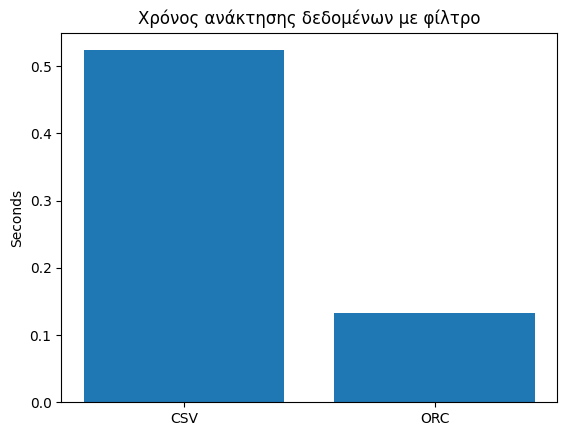

In [9]:
formats= ["CSV", "ORC"]
times= [csv_filter_time, orc_filter_time]

plt.bar(formats, times)
plt.title("Χρόνος ανάκτησης δεδομένων με φίλτρο")
plt.ylabel("Seconds")
plt.show()

**Συμπεράσματα**

1.   Το ORC ήταν πολύ μικρότερο από το CSV λόγο της columnar συμπίεση.
2.   Η ανάκτηση με φίλτρο στο ORC ήταν πολλές φορές ταχύτερη.
3.  ORC διαβάζει μόνο τις στήλες που χρειάζονται (αυτό μειώνει τον χρόνο ανάγνωσης).
4. Το ORC "παραλείπει" block δεδομένων που δεν ταιριάζουν στα φίλτρα σε σχέση με τον CSV που δεν έχει αυτή την δυνατότητα.

